# Social Network Analysis (CS342) | Assignment 1
## **Basic Concepts and Exploration of NetworkX in Python**

---

**Student Name :** *Naishadh Rana* <br>
**Roll. No :** U23CS014

---

---

## Task 1: Import networkx library (and other required libraries) 

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
print("Libraries imported.")

Libraries imported.


## Task 2: Create an empty graph and add nodes

In [4]:
G = nx.Graph() #empty graph

G.add_node(1) # individual nodes
G.add_node(2)
G.add_nodes_from([3, 4, 5]) # adding additional nodes (list)

print("Nodes in Graph G:", G.nodes())

Nodes in Graph G: [1, 2, 3, 4, 5]


## Task 3: Add edges to above graph

In [5]:
# Adding edges from a node to another node individually
G.add_edge(1, 2) # node 1 to 2
G.add_edge(1, 3) # node 1 to 3

G.add_edges_from([(2, 3), (2, 4), (3, 5), (4, 5)]) # adding multiple edges using a list of tuples

print("Edges in Graph G:", G.edges())

Edges in Graph G: [(1, 2), (1, 3), (2, 3), (2, 4), (3, 5), (4, 5)]


## Task 4: Create following types of graph: 
- Undirected Graph
- Directed Graph
- Multigraph
- Directed Multigraph
- Weighted Grap

In [6]:
# 1. Undirected Graph (Already created as G)
print("Undirected Graph G created.")

# 2. Directed Graph
DG = nx.DiGraph()
DG.add_edges_from([(1, 2), (2, 1), (2, 3), (3, 4)])
print("Directed Graph DG created.")

# 3. Multigraph (Allows multiple edges between same pair of nodes)
MG = nx.MultiGraph()
MG.add_edges_from([(1, 2), (1, 2), (2, 3)])
print("Multigraph MG created (note parallel edges between 1 and 2).")

# 4. Directed Multigraph
DMG = nx.MultiDiGraph()
DMG.add_edges_from([(1, 2), (1, 2), (2, 1)])
print("Directed Multigraph DMG created.")

# 5. Weighted Graph
WG = nx.Graph()
WG.add_edge(1, 2, weight=1.0)
WG.add_edge(2, 3, weight=1.2)
WG.add_edge(3, 4, weight=1.5)
print("Weighted Graph WG created.")

Undirected Graph G created.
Directed Graph DG created.
Multigraph MG created (note parallel edges between 1 and 2).
Directed Multigraph DMG created.
Weighted Graph WG created.


## Task 5 & 6: Remove edges and Display Adjacency Matrices
Removing edges and nodes, and showing the adjacency matrix before and after modification.

In [7]:
def display_adj_matrix(graph, name):
    print(f"\n Adjacency Matrix for {name} ")
    try:
        # Use simple dense conversion for display
        matrix = nx.adjacency_matrix(graph).todense()
        print(matrix)
    except Exception as e:
        print(f"Could not display matrix: {e}")

# Display Initial Matrices
display_adj_matrix(G, "Undirected Graph G (Initial)")
display_adj_matrix(DG, "Directed Graph DG (Initial)")

#  Task 5: Remove few edges 
print("\n[Action] Removing edge (1, 2) from G")
G.remove_edge(1, 2)

print("[Action] Removing edge (1, 2) from DG")
DG.remove_edge(1, 2)

#  Task 6 Logic: Remove a node to delete it clearly 
print("[Action] Removing node 3 from G")
G.remove_node(3)

# Display Matrices After Modifications
display_adj_matrix(G, "Undirected Graph G (After removing edge (1,2) and node 3)")
display_adj_matrix(DG, "Directed Graph DG (After removing edge (1,2))")


 Adjacency Matrix for Undirected Graph G (Initial) 
[[0 1 1 0 0]
 [1 0 1 1 0]
 [1 1 0 0 1]
 [0 1 0 0 1]
 [0 0 1 1 0]]

 Adjacency Matrix for Directed Graph DG (Initial) 
[[0 1 0 0]
 [1 0 1 0]
 [0 0 0 1]
 [0 0 0 0]]

[Action] Removing edge (1, 2) from G
[Action] Removing edge (1, 2) from DG
[Action] Removing node 3 from G

 Adjacency Matrix for Undirected Graph G (After removing edge (1,2) and node 3) 
[[0 0 0 0]
 [0 0 1 0]
 [0 1 0 1]
 [0 0 1 0]]

 Adjacency Matrix for Directed Graph DG (After removing edge (1,2)) 
[[0 0 0 0]
 [1 0 1 0]
 [0 0 0 1]
 [0 0 0 0]]


## Task 7: Visualize graphs
Visualizing the previously created graphs with `networkx.draw()` functions.

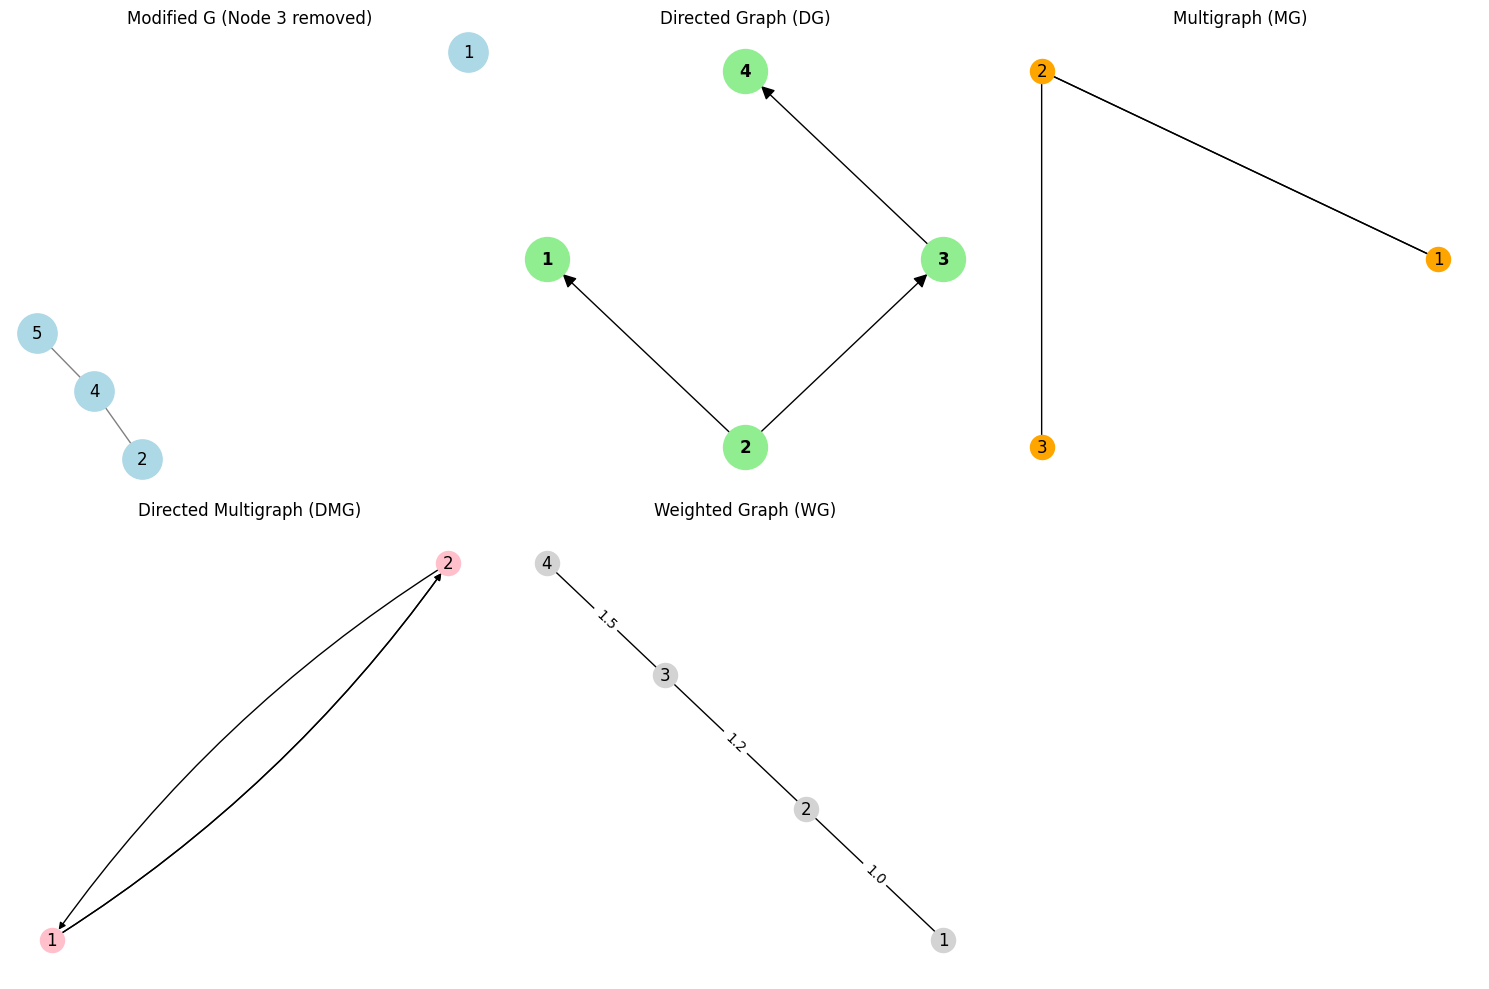

In [8]:
plt.figure(figsize=(15, 10))

# 1. Visualization of the modified Undirected Graph G
plt.subplot(2, 3, 1)
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', node_size=800)
plt.title("Modified G (Node 3 removed)")

# 2. Directed Graph DG with custom styling options (Task 8 exploration)
plt.subplot(2, 3, 2)
# Usage of shell_layout, specific colors, and arrow styling
nx.draw(DG, pos=nx.shell_layout(DG), with_labels=True, 
        node_color='lightgreen', font_weight='bold', 
        node_size=1000, arrowsize=20, arrowstyle='-|>')
plt.title("Directed Graph (DG)")

# 3. Multigraph MG 
plt.subplot(2, 3, 3)
# Circular layout
nx.draw_circular(MG, with_labels=True, node_color='orange')
plt.title("Multigraph (MG)")

# 4. Directed Multigraph DMG
plt.subplot(2, 3, 4)
nx.draw(DMG, with_labels=True, node_color='pink', connectionstyle='arc3, rad = 0.1')
plt.title("Directed Multigraph (DMG)")

# 5. Weighted Graph WG
plt.subplot(2, 3, 5)
pos = nx.spring_layout(WG)
nx.draw(WG, pos, with_labels=True, node_color='#D3D3D3')
# Draw edge labels to show weights
edge_labels = nx.get_edge_attributes(WG, 'weight')
nx.draw_networkx_edge_labels(WG, pos, edge_labels=edge_labels)
plt.title("Weighted Graph (WG)")

plt.tight_layout()
plt.show()

## Task 8: Explore different options in `networkx.draw()`
Exploring advanced options available in the drawing function, such as:
- **Node styling:** Shapes (`node_shape`), Colormaps (`cmap`), transparency (`alpha`), borders (`linewidths`, `edgecolors`).
- **Edge styling:** Styles (`style`), widths (`width`).
- **Font styling:** Size (`font_size`), color (`font_color`).

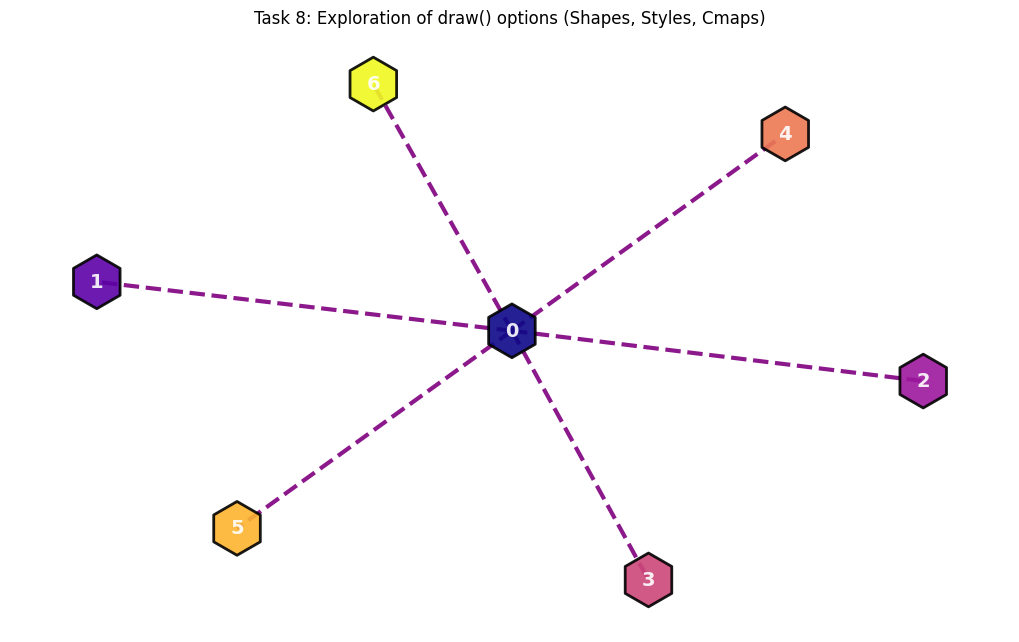

In [ ]:
plt.figure(figsize=(10, 6))

Explore_G = nx.star_graph(6)

nx.draw(
    Explore_G,
    with_labels=True,
    
    # Node Styling
    node_size=1500,
    node_color=range(len(Explore_G)), # Numeric values mapping to cmap
    cmap=plt.cm.plasma,              # Color map
    node_shape='h',                  # Hexagon shape
    alpha=0.9,                       # Transparency
    linewidths=2,                    # Node border width
    edgecolors='black',              # Node border color
    
    # Edge Styling
    width=3,                         # Edge width
    edge_color='purple',             # Edge color
    style='dashed',                  # Dashed line style
    
    # Font Styling
    font_size=14,
    font_color='white',
    font_weight='bold'
)

plt.title("Task 8: Exploration of draw() options (Shapes, Styles, Cmaps)")
plt.show()